# 📬 Customer Support Email Agent - Multiagent System
### LangGraph orchestrating LangChain Agents

---

## Version compatibility

This notebook is written and tested for:

| Package | Version |
|---|---|
| Python | 3.11.x |
| langchain | 1.3.x |
| langchain-openai | 1.2.x |
| langchain-community | 0.4.x |
| langgraph | 1.2.x (auto-installed) |
| openai | 2.x |


## What we're building

```
Gmail emails
     ↓
[classify_node]  ← LangChain create_agent
     ↓
     ├── support  → [summarize_node] → [draft_reply_node] → [save_notes_node] → END
     ├── feedback → [summarize_node] → [draft_reply_node] → [save_notes_node] → END
     └── ignore   ──────────────────────────────────────────────────────────── → END
```

---
## Section 1 — Install & Imports

In [ ]:
# Install langgraph (not in your list — required for StateGraph)
# Your other packages are already installed
# !pip install -qU langgraph

In [1]:
# Verify versions
import importlib.metadata
import sys

print("Python:", sys.version)

packages = ["langchain", "langchain-openai", "langchain-community", \
            "langgraph", "langchain-groq", "langchain-core", "openai"]
for pkg in packages:
    try:
        ver = importlib.metadata.version(pkg)
        print(f"  {pkg:<25}: {ver}")
    except importlib.metadata.PackageNotFoundError:
        print(f"  {pkg:<25}: NOT INSTALLED")

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
  langchain                : 1.3.11
  langchain-openai         : 1.3.3
  langchain-community      : 0.4.2
  langgraph                : 1.2.7
  langchain-groq           : 1.1.3
  langchain-core           : 1.4.8
  openai                   : 2.44.0


In [11]:
import os

from dotenv import load_dotenv
load_dotenv() # this load the .env file

# from getpass import getpass
# os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

print("Key set")

Key set


In [1]:
import json
import re
from typing import TypedDict, Literal, Optional

# LangGraph — state machine
from langgraph.graph import StateGraph, END

# LangChain — new unified agent API (langchain 1.3.x)
from langchain.agents import create_agent          
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage   

print("All  imports good")

All  imports good


In [3]:
import getpass
import os

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key:  ········


In [4]:
# All agents are sharing the same LLM


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
response = llm.invoke([HumanMessage(content="Hello. Reply with 1 word.")])

print("LLM response:", response.content)
print("LLM model connected successfully")

LLM response: Hello!
LLM model connected successfully


---
## Section 2 — The Shared State

In LangGraph every node reads from and writes to a **shared State** — a `TypedDict` that is the single source of truth flowing through the entire graph.

Each node only fills in the fields it is responsible for.

In [5]:
class EmailState(TypedDict):
    """
    Shared state passed between all LangGraph nodes.
    Fields are filled progressively as the email moves through the pipeline.
    """
    # INPUT — set at the start
    raw_email: str
    sender: str
    subject: str

    # FILLED BY classify_node
    email_type: Optional[str]              # 'support' | 'feedback' | 'ignore'
    classification_reason: Optional[str]

    # FILLED BY summarize_node
    summary: Optional[str]
    sentiment: Optional[str]               # 'positive' | 'neutral' | 'negative' | 'frustrated'
    urgency: Optional[str]                 # 'low' | 'medium' | 'high'
    key_issue: Optional[str]

    # FILLED BY draft_reply_node
    draft_reply: Optional[str]
    reply_tone: Optional[str]

    # FILLED BY save_notes_node
    note_saved: Optional[bool]
    note_content: Optional[str]


print(" EmailState schema defined")
print("Fields:", list(EmailState.__annotations__.keys()))

 EmailState schema defined
Fields: ['raw_email', 'sender', 'subject', 'email_type', 'classification_reason', 'summary', 'sentiment', 'urgency', 'key_issue', 'draft_reply', 'reply_tone', 'note_saved', 'note_content']


---
## Section 3 — Tools

Tools are Python functions decorated with `@tool`. Each agent sees the tool's **name** and **docstring** and decides when to call it.

We have two groups:
- **MCP-style tools** — Gmail and Google Drive (simulated here, real pattern shown in Section 9)
- **Custom analysis tools** — sentiment detection, tone selection

In [6]:
# ── Sample email data (simulates Gmail inbox) 
SAMPLE_EMAILS = [
    {
        "id": "email_001",
        "sender": "jane.doe@example.com",
        "subject": "My account is locked and I can't log in!",
        "body": (
            "Hi support team,\n\n"
            "I've been trying to log into my account since yesterday morning and I keep "
            "getting 'Account locked' error. I have an important presentation tomorrow and "
            "I NEED access to my files urgently. I've tried resetting my password twice and "
            "it still won't work. Please help ASAP!\n\nRegards,\nJane Doe"
        )
    },
    
    {
        "id": "email_002",
        "sender": "happy.user@example.com",
        "subject": "Love the new dashboard update!",
        "body": (
            "Hello,\n\n"
            "Just wanted to say the new dashboard layout is fantastic. It's so much easier "
            "to find everything now. One small suggestion: it would be great if you could "
            "add a dark mode. Overall though, really impressed with the direction things are "
            "going.\n\nThanks,\nAlex"
        )
    },
    
    {
        "id": "email_003",
        "sender": "noreply@newsletter.spam.com",
        "subject": "You've won a prize!! Click here NOW!",
        "body": "Congratulations! You are our lucky winner. Claim your $1000 gift card now."
    }
]

print(f" {len(SAMPLE_EMAILS)} sample emails loaded")

 3 sample emails loaded


In [7]:
# ── Simulated MCP tools 
# These have the same @tool interface as real MCP tools.
# To go live, replace the function body with the Anthropic/OPENAI API + mcp_servers call.

@tool
def fetch_unread_emails(max_results: int = 5) -> str:
    """Fetch unread emails from Gmail inbox.
    Returns a JSON list of emails with id, sender, subject, and body.
    Input: max_results — how many emails to return (default 5)."""
    return json.dumps(SAMPLE_EMAILS[:max_results], indent=2)


@tool
def save_note_to_drive(title: str, content: str, folder: str = "Email Triage Notes") -> str: # simulation
    """Save a structured note to Google Drive as a text document.
    Use this to log email summaries, drafted replies, and action items.
    Input: title (document name), content (document body), folder (Drive folder)."""
    print(f"[Drive] Saving '{title}' to '{folder}'") # This can be implemented based on client needs
    
    return f"Saved '{title}' to Google Drive / {folder}"


@tool
def apply_gmail_label(email_id: str, label: str) -> str:
    """Apply an organizational label to an email in Gmail.
    Common labels: 'Support/Urgent', 'Support/Normal', 'Feedback', 'Processed'.
    Input: email_id (from the email list), label (Gmail label string)."""
    print(f"    [Gmail] Label '{label}' → email {email_id}")
    return f"Label '{label}' applied to {email_id}"


# ── Custom analysis tools 

@tool
def detect_sentiment(text: str) -> str:
    """Detect the emotional sentiment of a customer email.
    Returns: 'positive', 'neutral', 'negative', or 'frustrated'.
    Input: the email body text to analyze."""
    text_lower = text.lower()
    if any(w in text_lower for w in ["asap", "urgent", "!!", "frustrated", "terrible",]):
        return "frustrated"
    elif any(w in text_lower for w in ["great", "love", "fantastic", "impressed", "thanks"]):
        return "positive"
    elif any(w in text_lower for w in ["issue", "problem", "error", "wrong", "not working", "locked"]):
        return "negative"
    return "neutral"


@tool
def set_reply_tone(email_type: str, sentiment: str) -> str:
    """Determine the best tone for a customer reply based on email type and sentiment.
    Returns: 'empathetic', 'apologetic', 'informational', or 'appreciative'.
    Input: email_type ('support' or 'feedback'), sentiment from detect_sentiment."""
    if email_type == "support" and sentiment in ["frustrated", "negative"]:
        return "apologetic"
    elif email_type == "support":
        return "empathetic"
    elif email_type == "feedback" and sentiment == "positive":
        return "appreciative"
    return "informational"


print("Tools defined:")
for t in [fetch_unread_emails, save_note_to_drive, apply_gmail_label, detect_sentiment, set_reply_tone]:
    print(f"  - {t.name}")

# Quick sanity check
print("\nSentiment test:", detect_sentiment.invoke("I can't log in ASAP urgent!!"))
print("Tone test:     ", set_reply_tone.invoke({"email_type": "support", "sentiment": "frustrated"}))

Tools defined:
  - fetch_unread_emails
  - save_note_to_drive
  - apply_gmail_label
  - detect_sentiment
  - set_reply_tone

Sentiment test: frustrated
Tone test:      apologetic


---
## Section 4 — Building Agents


The `create_agent` returns a `CompiledStateGraph` — it IS an agent executor already.

In [8]:
# ── Helper: build agent and call it 

def build_agent(system_prompt: str, tools: list):
    """Create a LangChain agent using the langchain 1.3.x API.
    Returns a CompiledStateGraph (already executable — no AgentExecutor needed)."""
    return create_agent(
        model=llm,
        tools=tools,
        system_prompt=system_prompt
    )

# ── Agent 1: Classifier 
classifier_agent = build_agent(
    system_prompt="""
        You are an email classification specialist.
        Classify emails into exactly one category:
          - 'support'  : Customer has a problem, error, or needs direct help
          - 'feedback' : Customer is sharing an opinion, suggestion, or compliment
          - 'ignore'   : Spam, automated messages, newsletters, or irrelevant
        
        Respond ONLY with valid JSON — no explanation, no markdown:
        {"email_type": "<type>", "reason": "<one sentence>"}
        """,
    tools=[] # Do not need tool. 
)

# ── Agent 2: Summarizer 
summarizer_agent = build_agent(
    system_prompt="""
        You are an expert at analyzing customer emails.
        Use the detect_sentiment tool to assess the customer's mood.
        Then respond ONLY with valid JSON — no explanation, no markdown:
        {
          "summary": "<2-3 sentence summary>",
          "sentiment": "<result from detect_sentiment tool>",
          "urgency": "<low|medium|high>",
          "key_issue": "<the core problem in 10 words or less>"
        }
    """,
    tools=[detect_sentiment]
)

# ── Agent 3: Reply drafter 
reply_agent = build_agent(
    system_prompt="""
        You are a professional customer support writer.
        First use the set_reply_tone tool to determine the right tone.
        Then write a professional, warm, concise reply email.
        Respond ONLY with valid JSON — no explanation, no markdown:
        {
          "reply_tone": "<result from set_reply_tone tool>",
          "draft_reply": "<full email reply including greeting and sign-off>"
        }
        Guidelines:
          - Support: acknowledge the issue, apologize if needed, outline next steps
          - Feedback: thank them, address their suggestion specifically
          - Keep it under 150 words
          - Sign off as: Best regards, Support Team
    """,
    tools=[set_reply_tone]
)

print("Three agents built ")

Three agents built 


In [9]:
# Quick test of the new invoke pattern (uses a tiny API call)

def run_agent(agent, user_message: str) -> str:
    """Invoke an agent with a message and return the final text response.
    
    NEW in langchain 1.3.x:
      - Input must be  {"messages": [HumanMessage(content="...")]}
      - Output is      {"messages": [...], "structured_response": ...}
      - Final answer   result["messages"][-1].content
    """
    result = agent.invoke({"messages": [HumanMessage(content=user_message)]})
    
    # The last message in the list is always the agent's final response
    return result["messages"][-1].content



print("Testing classifier agent with a sample email...")
test_response = run_agent(
    classifier_agent,
    "From: test@example.com\nSubject: Can't reset password\nBody: I've been trying to reset my password for 2 hours and the email never arrives."
)

print("Raw response:", test_response)


# Parse it
def extract_json(text: str) -> dict:
    """Safely extract the first JSON object from an LLM response."""
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r'\{[^{}]+\}', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except Exception:
                pass
    return {}

parsed = extract_json(test_response)
print("\nParsed      :", parsed)

Testing classifier agent with a sample email...
Raw response: {"email_type": "support", "reason": "Customer is experiencing an issue with resetting their password."}

Parsed      : {'email_type': 'support', 'reason': 'Customer is experiencing an issue with resetting their password.'}


---
## Section 5 — LangGraph Nodes

Each node is a plain Python function that:
1. Receives the full `EmailState`
2. Does its work (runs a LangChain agent or direct logic)
3. Returns a **dict of only the keys it changed**

LangGraph merges the returned dict back into the shared state automatically.

In [10]:
# ── Node 1: Classify 
def classify_node(state: EmailState) -> dict:
    """Reads: raw_email, subject, sender → Writes: email_type, classification_reason"""
    print("\n" + "=" * 60)
    print("NODE 1: Classifying email")
    print(f"   From   : {state['sender']}")
    print(f"   Subject: {state['subject']}")

    response = run_agent(
        classifier_agent,
        f"From: {state['sender']}\nSubject: {state['subject']}\nBody:\n{state['raw_email']}"
    )

    result = extract_json(response)
    email_type = result.get("email_type", "ignore")
    reason     = result.get("reason", "Could not determine type")

    print(f"   → Type: [{email_type.upper()}] — {reason}")
    return {"email_type": email_type, "classification_reason": reason}


# ── Routing function (conditional edge — NOT a node)
def route_by_type(state: EmailState) -> Literal["summarize", "skip"]:
    """Called by LangGraph after classify_node to decide the next node."""
    
    if state["email_type"] in ["support", "feedback"]:
        return "summarize"
    else:
        return "skip"
        
    
# ── Node 2: Summarize
def summarize_node(state: EmailState) -> dict:
    """Reads: raw_email, email_type → Writes: summary, sentiment, urgency, key_issue"""
    print("\n" + "=" * 60)
    print("NODE 2: Summarizing email")

    response = run_agent(
        summarizer_agent,
        f"Email type: {state['email_type']}\nSubject: {state['subject']}\nBody:\n{state['raw_email']}"
    )

    result   = extract_json(response)
    summary   = result.get("summary",   "No summary")
    sentiment = result.get("sentiment", "neutral")
    urgency   = result.get("urgency",   "medium")
    key_issue = result.get("key_issue", "Unspecified")

    print(f"   → Sentiment: {sentiment} | Urgency: {urgency}")
    print(f"   → Key issue: {key_issue}")

    return {"summary": summary, "sentiment": sentiment, "urgency": urgency, "key_issue": key_issue}


# ── Node 3: Draft reply 
def draft_reply_node(state: EmailState) -> dict:
    """Reads: email_type, sentiment, key_issue, raw_email → Writes: draft_reply, reply_tone"""
    print("\n" + "=" * 60)
    print("NODE 3: Drafting reply")

    response = run_agent(
        reply_agent,
        (
            f"Write a reply for this {state['email_type']} email.\n"
            f"Sender: {state['sender']}\n"
            f"Subject: {state['subject']}\n"
            f"Key issue: {state.get('key_issue', 'N/A')}\n"
            f"Sentiment: {state.get('sentiment', 'neutral')}\n"
            f"Summary: {state.get('summary', 'N/A')}\n"
            f"Original email:\n{state['raw_email']}"
        )
    )

    result = extract_json(response)
    # Fallback: if JSON parse fails, use raw response as the draft
    draft  = result.get("draft_reply", response)
    tone   = result.get("reply_tone",  "informational")

    print(f"   → Tone: {tone}")
    print(f"   → Preview: {draft[:100]}...")

    return {"draft_reply": draft, "reply_tone": tone}


# ── Node 4: Save notes
def save_notes_node(state: EmailState) -> dict:
    """Compiles a triage note and saves to Drive. Also labels the Gmail email."""
    print("\n" + "=" * 60)
    print("NODE 4: Saving notes")

    # Determine Gmail label
    label_map = {
        ("support",  "high"):   "Support/Urgent",
        ("support",  "medium"): "Support/Normal",
        ("support",  "low"):    "Support/Normal",
        ("feedback", "high"):   "Feedback/Important",
        ("feedback", "medium"): "Feedback/General",
        ("feedback", "low"):    "Feedback/General",
    }
    
    label = label_map.get(
        (state.get("email_type", "support"), state.get("urgency", "medium")),
        "Support/Normal"
    )

    # Apply label (tool called directly — no agent overhead needed)
    apply_gmail_label.invoke({"email_id": "email_001", "label": label})

    # Build the structured note
    note_content = (
        f"Email Triage Report\n{'='*40}\n"
        f"From     : {state['sender']}\n"
        f"Subject  : {state['subject']}\n"
        f"Type     : {state.get('email_type','N/A').upper()}\n"
        f"Urgency  : {state.get('urgency','N/A').upper()}\n"
        f"Sentiment: {state.get('sentiment','N/A')}\n"
        f"Label    : {label}\n\n"
        f"KEY ISSUE\n{state.get('key_issue','N/A')}\n\n"
        f"SUMMARY\n{state.get('summary','N/A')}\n\n"
        f"DRAFTED REPLY\n{state.get('draft_reply','N/A')}\n"
    )

    # Save to Google Drive
    save_note_to_drive.invoke({
        "title": f"Triage: {state['subject'][:40]}",
        "content": note_content,
        "folder": "Email Triage Notes"
    })

    print("   → Note saved!")
    return {"note_saved": True, "note_content": note_content}


# ── Node 5: Skip (for ignored emails)
def skip_node(state: EmailState) -> dict:
    """No-op — called when email_type is 'ignore'."""
    print("\n" + "=" * 60)
    print("NODE SKIP: Email is spam/irrelevant — no action taken.")
    return {"note_saved": False}


print("All 5 nodes defined")

All 5 nodes defined


---
## Section 6 — Build & Compile the LangGraph

We now wire all nodes together. Key concepts:

- `add_node(name, fn)` — registers a node function
- `set_entry_point(name)` — which node runs first
- `add_conditional_edges(source, path_fn, path_map)` — branches based on state
- `add_edge(a, b)` — linear connection from a → b
- `compile()` — validates and locks the graph

In [11]:
# Build the graph
graph = StateGraph(EmailState)

# Register nodes
graph.add_node("classify",    classify_node)
graph.add_node("summarize",   summarize_node)
graph.add_node("draft_reply", draft_reply_node)
graph.add_node("save_notes",  save_notes_node)
graph.add_node("skip",        skip_node)

# Entry point
graph.set_entry_point("classify")

# Conditional branch after classify
graph.add_conditional_edges(
    source="classify",
    path=route_by_type,
    path_map={"summarize": "summarize", "skip": "skip"}
)

# Linear edges
graph.add_edge("summarize",   "draft_reply")
graph.add_edge("draft_reply", "save_notes")
graph.add_edge("save_notes",  END)
graph.add_edge("skip",        END)

# Compile
app = graph.compile()

print("Graph compiled!")
print("Nodes:", list(graph.nodes.keys()))

Graph compiled!
Nodes: ['classify', 'summarize', 'draft_reply', 'save_notes', 'skip']


Graph saved using local dependencies.


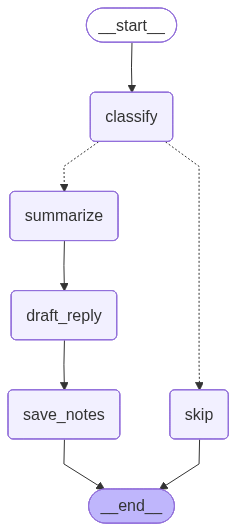

In [12]:
# # Visualize the graph as a Mermaid diagram

try:
    with open("graph.png", "wb") as f:
        f.write(app.get_graph().draw_mermaid_png())
    print("Graph saved using local dependencies.")
except Exception as e:
    print(f"Local rendering failed: {e}. Use the URL/Requests method instead.")

from IPython.display import Image, display

# Display the locally saved file
display(Image(filename="graph.png"))

---
## Section 7 — Run the Pipeline

In [33]:
def make_initial_state(email: dict) -> EmailState:
    """Create the starting state from a raw email dict."""
    return EmailState(
        raw_email=email["body"],
        sender=email["sender"],
        subject=email["subject"],
        email_type=None,
        classification_reason=None,
        summary=None,
        sentiment=None,
        urgency=None,
        key_issue=None,
        draft_reply=None,
        reply_tone=None,
        note_saved=None,
        note_content=None,
    )


def process_email(email: dict) -> EmailState:
    """Run email through the full LangGraph pipeline."""
    print(f"\n{'#'*60}")
    print(f"# Processing: {email['subject']}")
    print(f"{'#'*60}")
    return app.invoke(make_initial_state(email))


# ── Email 1: Support (locked account, urgent)
result_1 = process_email(SAMPLE_EMAILS[0])


############################################################
# Processing: My account is locked and I can't log in!
############################################################

NODE 1: Classifying email
   From   : jane.doe@example.com
   Subject: My account is locked and I can't log in!
   → Type: [SUPPORT] — Customer is experiencing a login issue and needs urgent assistance.

NODE 2: Summarizing email
   → Sentiment: frustrated | Urgency: high
   → Key issue: Account locked preventing access to important files

NODE 3: Drafting reply
   → Tone: apologetic
   → Preview: Dear Jane,

I’m truly sorry to hear that you’re locked out of your account, especially with an impor...

💾 NODE 4: Saving notes
    [Gmail] Label 'Support/Urgent' → email email_001
    [Drive] Saving 'Triage: My account is locked and I can't log in!' to 'Email Triage Notes'
   → Note saved!


In [34]:
# Print results for email 1
print("\n" + "="*60)
print("FINAL STATE — Email 1 (support)")
print("="*60)
for key, val in result_1.items():
    if key in ("note_content", "draft_reply", "raw_email"):
        continue
    print(f"  {key:<25}: {val}")

print("\n--- DRAFTED REPLY ---")
print(result_1.get("draft_reply", "N/A"))

print("\n--- TRIAGE NOTE (saved to Drive) ---")
print(result_1.get("note_content", "N/A"))


FINAL STATE — Email 1 (support)
  sender                   : jane.doe@example.com
  subject                  : My account is locked and I can't log in!
  email_type               : support
  classification_reason    : Customer is experiencing a login issue and needs urgent assistance.
  summary                  : The customer is frustrated due to being locked out of their account. They urgently need access for an important presentation.
  sentiment                : frustrated
  urgency                  : high
  key_issue                : Account locked preventing access to important files
  reply_tone               : apologetic
  note_saved               : True

--- DRAFTED REPLY ---
Dear Jane,

I’m truly sorry to hear that you’re locked out of your account, especially with an important presentation coming up. We understand how urgent this is and are here to help.

To resolve this issue quickly, I will escalate your case to our technical team right away. They will assist you in unlock

In [35]:
# ── Email 2: Feedback (positive, dark mode suggestion) 
result_2 = process_email(SAMPLE_EMAILS[1])

print("\n--- DRAFTED REPLY ---")
print(result_2.get("draft_reply", "N/A"))


############################################################
# Processing: Love the new dashboard update!
############################################################

NODE 1: Classifying email
   From   : happy.user@example.com
   Subject: Love the new dashboard update!
   → Type: [FEEDBACK] — Customer is sharing a positive opinion about the dashboard update and suggesting a feature.

NODE 2: Summarizing email
   → Sentiment: positive | Urgency: low
   → Key issue: Suggestion for adding dark mode feature

NODE 3: Drafting reply
   → Tone: appreciative
   → Preview: Dear Alex,

Thank you so much for your kind words about the new dashboard update! We're thrilled to ...

💾 NODE 4: Saving notes
    [Gmail] Label 'Feedback/General' → email email_001
    [Drive] Saving 'Triage: Love the new dashboard update!' to 'Email Triage Notes'
   → Note saved!

--- DRAFTED REPLY ---
Dear Alex,

Thank you so much for your kind words about the new dashboard update! We're thrilled to hear that you find 

In [36]:
# ── Email 3: Spam — should be IGNORED with no reply
result_3 = process_email(SAMPLE_EMAILS[2])

print("\nSpam email result:")
print(f"  email_type  : {result_3.get('email_type')}")
print(f"  note_saved  : {result_3.get('note_saved')}")
print(f"  draft_reply : {result_3.get('draft_reply')}  ← correctly None")


############################################################
# Processing: You've won a prize!! Click here NOW!
############################################################

NODE 1: Classifying email
   From   : noreply@newsletter.spam.com
   Subject: You've won a prize!! Click here NOW!
   → Type: [IGNORE] — This is a spam message promoting a prize that likely does not exist.

NODE SKIP: Email is spam/irrelevant — no action taken.

Spam email result:
  email_type  : ignore
  note_saved  : False
  draft_reply : None  ← correctly None


---
## Section 8 — Stream the Graph (Step-by-Step)

`app.stream()` yields the state delta after every node fires — great for debugging and building live progress UIs.

In [37]:
print("Streaming email 2 (feedback) through the graph:\n")

for step in app.stream(make_initial_state(SAMPLE_EMAILS[1])):
    node_name    = list(step.keys())[0]
    state_update = step[node_name]

    print(f"\n🔵 Node fired: [{node_name}]")
    print("   Fields written:")
    for k, v in state_update.items():
        if v is not None:
            preview = str(v)[:80] + "..." if len(str(v)) > 80 else str(v)
            print(f"     {k}: {preview}")

Streaming email 2 (feedback) through the graph:


NODE 1: Classifying email
   From   : happy.user@example.com
   Subject: Love the new dashboard update!
   → Type: [FEEDBACK] — Customer is sharing a positive opinion about the dashboard update and suggesting a feature.

🔵 Node fired: [classify]
   Fields written:
     email_type: feedback
     classification_reason: Customer is sharing a positive opinion about the dashboard update and suggesting...

NODE 2: Summarizing email
   → Sentiment: positive | Urgency: low
   → Key issue: Suggestion for adding dark mode feature

🔵 Node fired: [summarize]
   Fields written:
     summary: Alex is very pleased with the new dashboard update and finds it user-friendly. H...
     sentiment: positive
     urgency: low
     key_issue: Suggestion for adding dark mode feature

NODE 3: Drafting reply
   → Tone: appreciative
   → Preview: Dear Alex,

Thank you so much for your kind words about the new dashboard! We're thrilled to hear th...

🔵 Node fired: 

---
## Section 9 — Real MCP Integration

The simulated tools above use the identical `@tool` interface as real MCP tools.
To go live, replace the function body with an LLM API call using `mcp_servers`.

In [26]:
REAL_MCP_PATTERN = '''
# ── Real MCP integration pattern ──────────────────────────────────────────
# Requires: pip install anthropic
# Requires: Gmail and Google Drive MCPs connected in LLM

import anthropic
client = anthropic.Anthropic()  # uses ANTHROPIC_API_KEY env var

# 1. Fetch real emails via Gmail MCP
response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=2000,
    messages=[{"role": "user", "content":
        "List my 5 most recent unread emails. Return as JSON with fields:"
        "id, sender, subject, body."}],
    mcp_servers=[{
        "type": "url",
        "url" : "https://gmailmcp.googleapis.com/mcp/v1",
        "name": "gmail"
    }]
)

# 2. Extract email data from MCP tool_result blocks
emails = []
for block in response.content:
    if block.type == "mcp_tool_result":
        emails = json.loads(block.content[0].text)

# 3. Run each email through the LangGraph pipeline (same as above)
for email in emails:
    result = process_email(email)

    # 4. Save note to real Google Drive via MCP
    client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=500,
        messages=[{"role": "user", "content":
            f"Create a Google Doc titled \'Triage: {result[\'subject\']}\' "
            f"with this content:\n{result[\'note_content\']}"}],
        mcp_servers=[{
            "type": "url",
            "url" : "https://drivemcp.googleapis.com/mcp/v1",
            "name": "drive"
        }]
    )
    print(f"Processed and saved: {result[\'subject\']}")
'''

print(REAL_MCP_PATTERN)


# ── Real MCP integration pattern ──────────────────────────────────────────
# Requires: pip install anthropic
# Requires: Gmail and Google Drive MCPs connected in Claude.ai

import anthropic
client = anthropic.Anthropic()  # uses ANTHROPIC_API_KEY env var

# 1. Fetch real emails via Gmail MCP
response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=2000,
    messages=[{"role": "user", "content":
        "List my 5 most recent unread emails. Return as JSON with fields:"
        "id, sender, subject, body."}],
    mcp_servers=[{
        "type": "url",
        "url" : "https://gmailmcp.googleapis.com/mcp/v1",
        "name": "gmail"
    }]
)

# 2. Extract email data from MCP tool_result blocks
emails = []
for block in response.content:
    if block.type == "mcp_tool_result":
        emails = json.loads(block.content[0].text)

# 3. Run each email through the LangGraph pipeline (same as above)
for email in emails:
    result = process_email(email)

    # 4. Save no

---
## Section 10 — Batch Triage Report

In [27]:
results = [result_1, result_2, result_3]  # reuse already-processed results
emails  = SAMPLE_EMAILS

print("\n" + "="*65)
print("📊 INBOX TRIAGE REPORT")
print("="*65)
print(f"{'Subject':<35} {'Type':<10} {'Urgency':<8} {'Sentiment':<12} {'Reply?'}")
print("-"*65)

for email, r in zip(emails, results):
    subj = (email['subject'][:32] + '...') if len(email['subject']) > 32 else email['subject']
    icon = '✅' if r.get('draft_reply') else '—'
    print(
        f"{subj:<35} "
        f"{str(r.get('email_type','N/A')):<10} "
        f"{str(r.get('urgency','—')):<8} "
        f"{str(r.get('sentiment','—')):<12} "
        f"{icon}"
    )

print("="*65)
types = [r.get('email_type','ignore') for r in results]
print(f"  Support: {types.count('support')}  |  Feedback: {types.count('feedback')}  |  Ignored: {types.count('ignore')}")


📊 INBOX TRIAGE REPORT
Subject                             Type       Urgency  Sentiment    Reply?
-----------------------------------------------------------------
My account is locked and I can't... support    high     frustrated   ✅
Love the new dashboard update!      feedback   low      positive     ✅
You've won a prize!! Click here ... ignore     None     None         —
  Support: 1  |  Feedback: 1  |  Ignored: 1


---
## 📚 Summary — What We Used

### LangGraph (graph / flow control)
| API | What it does |
|---|---|
| `StateGraph(EmailState)` | Create graph with a TypedDict state schema |
| `add_node(name, fn)` | Register a node function |
| `set_entry_point(name)` | First node to run |
| `add_conditional_edges(src, fn, map)` | Branch based on state value |
| `add_edge(a, b)` | Linear connection |
| `compile()` | Lock and validate the graph |
| `app.invoke(state)` | Run to completion |
| `app.stream(state)` | Step-by-step execution |

### LangChain 1.3.x (agent / tool use)
| API | What it does |
|---|---|
| `create_agent(model, tools, system_prompt)` | Build an agent (replaces old `AgentExecutor`) |
| `@tool` decorator | Turn any function into an agent tool |
| `agent.invoke({"messages": [HumanMessage(...)]})` | New invoke format |
| `result["messages"][-1].content` | Extract the final response |